In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import gaussian
from skimage.segmentation import active_contour


img = data.astronaut()
img = rgb2gray(img)

s = np.linspace(0, 2 * np.pi, 400)
r = 100 + 100 * np.sin(s)
c = 220 + 100 * np.cos(s)
init = np.array([r, c]).T

snake = active_contour(
    gaussian(img, sigma=3, preserve_range=False),
    init,
    alpha=0.015,
    beta=10,
    gamma=0.001,
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--r', lw=3)
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3)
ax.set_xticks([]), ax.set_yticks([])
ax.axis([0, img.shape[1], img.shape[0], 0])

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from scipy.interpolate import splprep, splev
import cv2


C:\Users\arfib\AppData\Local\Temp\ipykernel_21404\630921761.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  points = plt.ginput(n=-1, timeout=0)  # n=-1 => nombre libre de points


KeyboardInterrupt: 

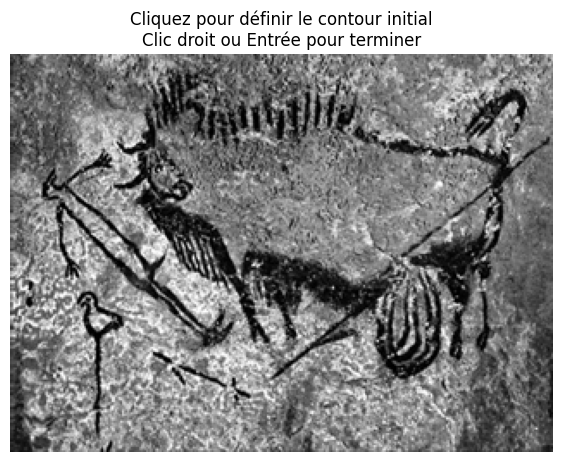

In [3]:
# Charger l'image
img = cv2.imread("Segmentation-of-Cave-Paintings/dataset/lascaux/Lascaux_01.jpg")  # image couleur ou niveaux de gris
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Affichage pour sélection des points
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap="gray")
ax.set_title("Cliquez pour définir le contour initial\nClic droit ou Entrée pour terminer")
ax.axis("off")

# Sélection interactive
points = plt.ginput(n=-1, timeout=0)  # n=-1 => nombre libre de points
plt.close(fig)

points = np.array(points)  # shape (N, 2) avec (x, y)


In [ ]:
# Fermer le contour
points = np.vstack([points, points[0]])

# Interpolation spline fermée
tck, u = splprep([points[:, 0], points[:, 1]], s=0, per=True)
u_new = np.linspace(0, 1, 400)  # nombre de points du contour initial
x_new, y_new = splev(u_new, tck)

# Format attendu par active_contour : (row, col)
init = np.array([y_new, x_new]).T


In [ ]:
snake = active_contour(
    gaussian(img, sigma=3, preserve_range=False),
    init,
    alpha=0.015,
    beta=10,
    gamma=0.001,
)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap="gray")
ax.plot(init[:, 1], init[:, 0], '--r', lw=2, label="Initial (utilisateur)")
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=2, label="Snake final")
ax.legend()
ax.axis([0, img.shape[1], img.shape[0], 0])
ax.set_xticks([]), ax.set_yticks([])
plt.show()
